# 🌱 Análise de Agrupamento de Municípios para Avaliação Ambiental no Estado do Pará

## 📌 Objetivo do Projeto

Este projeto tem como objetivo aplicar técnicas de Ciência de Dados e Inteligência Artificial para **agrupar municípios do estado do Pará** com base em **indicadores ambientais e socioeconômicos**. A intenção é descobrir **padrões ocultos** nos dados que possam auxiliar na **tomada de decisões públicas, estratégias de conservação ambiental** e priorização de ações.

## 🧪 Metodologia

1. **Carregamento dos Dados**
   - Leitura dos dados ambientais e sociais por comunidade no estado do Pará.

2. **Agrupamento por Município**
   - Agrega os dados por município (média das comunidades) para evitar sobrepeso em regiões com mais registros.

3. **Padronização dos Dados**
   - Normaliza as variáveis numéricas para média 0 e desvio padrão 1, garantindo comparabilidade entre indicadores com escalas diferentes.

4. **Redução de Dimensionalidade com PCA**
   - Aplica PCA para transformar as variáveis em componentes principais.
   - Mantém os 4 primeiros PCs, que explicam ~74% da variância total dos dados.

5. **Método do Cotovelo sobre os Componentes Principais**
   - Determina o número ideal de clusters analisando a queda de inércia no espaço PCA.

6. **Clustering com K-Means**
   - Aplica o algoritmo K-Means sobre os dados transformados pela PCA com o número ideal de `k` (ex: 4 clusters).

7. **Visualização dos Resultados**
   - Geração de gráficos 2D (PCA1 vs PCA2), gráficos de barras das médias por cluster, e mapas interativos com cores por grupo.

8. **Análise e Interpretação dos Clusters**
   - Interpreta o perfil de cada cluster com base nos componentes principais e nas médias das variáveis originais.

In [1]:
# Importação das Bibliotecas
import pandas as pd
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np


## Carregando o Dataset

In [2]:
df_municipios = pd.read_csv('Dataset_de_200_Comunidades_para_Analise_Ambiental.csv')
df_municipios.head()

,Comunidade,Município,Estado,Índice de Desmatamento (%),Acesso à Água Potável (%),Cobertura Vegetal (%),Renda Média Mensal (R$),Densidade Populacional (hab/km²),Frequência de Queimadas (ano),Distância de Área Urbana (km),Presença de Escola (Sim/Não),Presença de Unidade de Saúde (Sim/Não)
0,Comunidade 1,SÃO DOMINGOS DO CAPIM,Pará,25.6,86.5,22.9,2863.0,123.2,0,74.7,Sim,Não
1,Comunidade 2,SALINÓPOLIS,Pará,12.9,99.3,21.8,799.0,120.3,11,87.3,Sim,Não
2,Comunidade 3,TRACUATEUA,Pará,81.3,58.9,64.5,1924.0,104.8,5,43.9,Não,Sim
3,Comunidade 4,SÃO MIGUEL DO GUAMÁ,Pará,81.5,56.0,25.5,1715.0,42.3,0,5.3,Sim,Sim
4,Comunidade 5,MAGALHÃES BARATA,Pará,58.8,84.3,39.4,1990.0,89.4,9,17.0,Sim,Sim


## 📈 Variáveis Utilizadas

- Índice de Desmatamento (%)
- Cobertura Vegetal (%)
- Acesso à Água Potável (%)
- Densidade Populacional (hab/km²)
- Frequência de Queimadas (ano)
- Distância de Área Urbana (km)

Essas variáveis foram selecionadas por representarem diferentes dimensões da realidade ambiental e social dos municípios analisados.



In [3]:
features = [
    'Índice de Desmatamento (%)',
    'Cobertura Vegetal (%)',
    'Acesso à Água Potável (%)',
    'Renda Média Mensal (R$)',
    'Densidade Populacional (hab/km²)',
    'Frequência de Queimadas (ano)',
    'Distância de Área Urbana (km)'
]

## 🏙️ Agrupamento por Município

Como temos várias comunidades por município, fazemos a média dos dados para que cada cidade entre apenas uma vez na análise, com um valor representativo geral. Assim, evitamos duplicidade e garantimos uma comparação equilibrada entre os municípios. Caso não fizisse isso, poderia ocasionar :


- Repetição de municípios no clustering

- Distorção nos resultados (municípios com mais comunidades influenciam mais)

- Sobreposição de pontos no mapa interativo

## ✅ Vantagens do agrupamento:
- Cada município é representado por um único vetor de características médias

- Permite uma análise justa e balanceada entre municípios

- Ideal para visualização em mapas, já que cada cidade aparece uma vez

In [4]:
df_municipios = df_municipios.groupby('Município')[features].mean().reset_index()
df_municipios.head()

,Município,Índice de Desmatamento (%),Cobertura Vegetal (%),Acesso à Água Potável (%),Renda Média Mensal (R$),Densidade Populacional (hab/km²),Frequência de Queimadas (ano),Distância de Área Urbana (km)
0,ACARÁ,58.15,43.25,85.55,1805.0,9.90,9.0,39.75
1,ALENQUER,29.10,32.20,68.60,1180.5,68.00,7.5,42.30
2,ALMEIRIM,32.50,78.80,87.60,1289.0,114.20,8.0,24.20
3,ALTAMIRA,54.20,89.00,70.90,2480.0,141.80,8.0,11.20
4,ANAJÁS,25.80,25.20,68.25,1722.0,114.35,5.0,86.15


## ⚙️ Padronização dos Dados com StandardScaler

### 📌 O que é o `StandardScaler`?

O `StandardScaler` é uma ferramenta da biblioteca `scikit-learn` que **padroniza variáveis numéricas**.  
Ele transforma os dados para que cada coluna tenha:

- **Média = 0**
- **Desvio padrão = 1**

Essa transformação é chamada de **normalização z-score** e é feita com a fórmula:

$$
z = \frac{x - \text{média}}{\text{desvio padrão}}
$$


---

### ❓ Por que isso é necessário?

Algoritmos como o **K-Means** (e também o **MiniBatchKMeans**) calculam **distâncias** entre pontos (normalmente distância Euclidiana).  
Se as variáveis tiverem **escalas diferentes**, isso gera problemas.

**Exemplo de variáveis em escalas distintas:**
- `Distância de Área Urbana (km)` → pode variar de 0 a 100+
- `Acesso à Água Potável (%)` → varia de 0 a 100
- `Frequência de Queimadas` → geralmente entre 0 e 20

➡️ Sem padronizar, a variável com maior escala **domina** a formação dos clusters.

---

### ✅ Vantagens da padronização com `StandardScaler`:

| Benefício | Por que importa? |
|-----------|------------------|
| Evita viés por escala | Nenhuma variável domina a análise |
| Garante comparabilidade | Todas as variáveis têm o mesmo "peso" |
| Essencial para K-Means | O algoritmo depende de distância para formar os clusters |
| Facilita PCA | PCA também é sensível à escala das variáveis |


In [5]:
# Remover valores nulos nas colunas selecionadas
df_clustering = df_municipios.dropna().copy()

# Padronizar os dados
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clustering[features])

#Padronizados para ajustar o modelo
data_to_fit = scaled_data

## 🔍 Análise de Componentes Principais (PCA)

### 📌 O que é PCA?

A **PCA (Principal Component Analysis)** é uma técnica estatística usada para **reduzir a dimensionalidade de um conjunto de dados**, mantendo o máximo possível da informação original.

Ela transforma as variáveis originais (como desmatamento, vegetação, queimada etc.) em **novas variáveis chamadas componentes principais**, que são combinações lineares das variáveis originais.

---

### 🎯 Por que usar PCA neste projeto?

- O conjunto de dados possui **múltiplas variáveis ambientais e sociais**.
- Muitas dessas variáveis podem estar **correlacionadas entre si** (ex: desmatamento e cobertura vegetal).
- A PCA ajuda a:
  - **Remover redundância**
  - **Reduzir o ruído**
  - **Simplificar o espaço de análise**
- E ainda **mantém a maior parte da variância** (informação) dos dados.

---

### ⚙️ O que a PCA faz?

1. Calcula a **variância de cada variável** e como elas se relacionam.
2. Gera novos eixos (componentes principais) que são:
   - **Ortogonais entre si** (sem correlação)
   - Ordenados pela quantidade de informação (variância) que carregam
3. Os primeiros componentes **explicam a maior parte dos padrões dos dados**.

---

### 📈 Resultados da PCA - Variância Explicada

A PCA gerou os seguintes valores de variância explicada por componente:

| Componente Principal | Variância Explicada | Variância Acumulada |
|----------------------|---------------------|----------------------|
| PC1                  | 21.31%              | 21.31%               |
| PC2                  | 18.00%              | 39.32%               |
| PC3                  | 15.84%              | 55.15%               |
| PC4                  | 13.08%              | 68.23%               |
| PC5                  | 12.66%              | 80.89%               |
| PC6                  | 9.93%               | 90.82%               |
| PC7                  | 9.18%               | 100.00%              |

➡️ Com isso, percebemos que os **5 primeiros componentes principais explicam aproximadamente 81% da variância** dos dados.

---

### 📌 O que isso significa?

- Podemos usar apenas os **5 primeiros componentes** e manter **a maior parte da informação original**.
- Isso **simplifica os dados**, reduz a complexidade e melhora o desempenho de algoritmos como o **K-Means**.
- Permite **visualizações mais claras** e agrupamentos mais estáveis.

---

### 🎯 Aplicação prática

- No projeto, foram utilizados os **5 primeiros componentes principais** como base para o algoritmo de clusterização (K-Means).
- Esse espaço reduzido representa melhor os padrões globais dos municípios e elimina ruídos ou sobreposição entre variáveis.



In [6]:
# Aplicar PCA. Vamos calcular todos os componentes principais inicialmente
pca = PCA()
pca.fit(scaled_data)

# Explicando a variância de cada componente
explained_variance_ratio = pca.explained_variance_ratio_
print("Variância explicada por cada componente principal:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"  Componente Principal {i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

Variância explicada por cada componente principal:
  Componente Principal 1: 0.2131 (21.31%)
  Componente Principal 2: 0.1800 (18.00%)
  Componente Principal 3: 0.1584 (15.84%)
  Componente Principal 4: 0.1308 (13.08%)
  Componente Principal 5: 0.1266 (12.66%)
  Componente Principal 6: 0.0993 (9.93%)
  Componente Principal 7: 0.0918 (9.18%)


In [7]:
# Variância acumulada
cumulative_variance_ratio = explained_variance_ratio.cumsum()
print("\nVariância acumulada:")
for i, ratio in enumerate(cumulative_variance_ratio):
    print(f"  Até Componente Principal {i+1}: {ratio:.4f} ({ratio*100:.2f}%)")



Variância acumulada:
  Até Componente Principal 1: 0.2131 (21.31%)
  Até Componente Principal 2: 0.3932 (39.32%)
  Até Componente Principal 3: 0.5515 (55.15%)
  Até Componente Principal 4: 0.6823 (68.23%)
  Até Componente Principal 5: 0.8089 (80.89%)
  Até Componente Principal 6: 0.9082 (90.82%)
  Até Componente Principal 7: 1.0000 (100.00%)


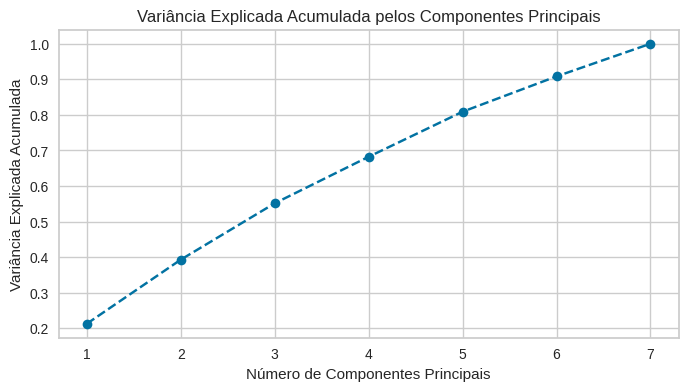

In [8]:
# Plot da variância explicada acumulada para ajudar a escolher o número de componentes
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='--')
plt.title('Variância Explicada Acumulada pelos Componentes Principais')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(True)
plt.show()

## 🧠 Interpretação dos Componentes Principais (PCA)

Com base nos *loadings* (pesos de contribuição) de cada variável nos componentes, é possível interpretar **o que cada Componente Principal representa** no contexto ambiental e socioeconômico dos municípios do Pará.

---

### 📊 **Componente Principal 1 (PC1)**  
**Principais variáveis**:  
- Densidade Populacional (hab/km²)  
- Cobertura Vegetal (%)  
- Renda Média Mensal (R$)  
- Acesso à Água Potável (%)

**Interpretação**:  
Esse componente resume uma **dimensão socioambiental integrada**, que relaciona:
- **Áreas mais urbanizadas** (alta densidade)
- Com **maior cobertura vegetal**
- E **melhores condições socioeconômicas** (renda e água potável)

---

### 📊 **Componente Principal 2 (PC2)**  
**Principais variáveis**:  
- Distância de Área Urbana (km)  
- Frequência de Queimadas (ano)  
- Índice de Desmatamento (%)  
- Cobertura Vegetal (%)  
- Renda Média Mensal (R$)

**Interpretação**:  
Representa um **eixo de isolamento e pressão ambiental**:
- Comunidades mais afastadas dos centros urbanos
- Com **mais queimadas e desmatamento**
- E variações na cobertura vegetal e renda

---

### 📊 **Componente Principal 3 (PC3)**  
**Principais variáveis**:  
- Frequência de Queimadas (ano)  
- Índice de Desmatamento (%)  
- Distância de Área Urbana (km)  
- Renda Média Mensal (R$)  
- Densidade Populacional (hab/km²)

**Interpretação**:  
Reflete um **cenário de vulnerabilidade ambiental e pressão humana**, mesclando:
- Altas taxas de queimada e desmatamento
- Com variações na renda, densidade e localização

---

### 📊 **Componente Principal 4 (PC4)**  
**Principais variáveis**:  
- Índice de Desmatamento (%)  
- Frequência de Queimadas (ano)  
- Acesso à Água Potável (%)

**Interpretação**:  
Retrata áreas com **intensa pressão ambiental e infraestrutura básica precária**, onde:
- Há muita degradação ambiental
- E **baixo acesso a serviços essenciais**

---

### 📊 **Componente Principal 5 (PC5)**  
**Principais variáveis**:  
- Acesso à Água Potável (%)  
- Índice de Desmatamento (%)  
- Densidade Populacional (hab/km²)

**Interpretação**:  
Aponta **desigualdades básicas**, onde municípios com baixa densidade e desmatamento elevado também podem apresentar **deficiências em serviços essenciais como água potável**.

---

### 📊 **Componente Principal 6 (PC6)**  
**Principais variáveis**:  
- Cobertura Vegetal (%)  
- Distância de Área Urbana (km)  
- Renda Média Mensal (R$)  
- Densidade Populacional (hab/km²)

**Interpretação**:  
Agrupa municípios com **características rurais ou isoladas**, combinando vegetação mais presente, baixa densidade e variação na renda.

---

### 📊 **Componente Principal 7 (PC7)**  
**Principais variáveis**:  
- Densidade Populacional (hab/km²)  
- Renda Média Mensal (R$)  
- Frequência de Queimadas (ano)

**Interpretação**:  
Relaciona **dinâmica populacional e econômica com impactos ambientais**, revelando possíveis zonas de urbanização com pressão sobre o meio ambiente.

---

### ✅ Conclusão

Essa interpretação permite entender **quais aspectos ambientais e sociais estão mais interligados** em cada dimensão do problema. Ela é essencial para:

- **Nomear e interpretar clusters** formados pelo K-Means
- **Explicar a lógica de separação dos grupos**
- **Guiar políticas públicas** com base em características dominantes de cada município



In [9]:
pca_components = pca.components_

print("\nLoadings dos Componentes Principais:")
print("Componente | " + " | ".join(features))
print("-" * (11 + (len(" | ".join(features)))))

for i, component in enumerate(pca_components):
    # Ordenar os loadings por valor absoluto para identificar as features mais importantes para este componente
    sorted_indices = abs(component).argsort()[::-1] # Indices das features em ordem decrescente de importância
    sorted_features = [features[j] for j in sorted_indices]
    sorted_loadings = [component[j] for j in sorted_indices]

    print(f"PC {i+1:<8} | " + " | ".join([f"{l:.3f} ({f})" for f, l in zip(sorted_features, sorted_loadings)]))


Loadings dos Componentes Principais:
Componente | Índice de Desmatamento (%) | Cobertura Vegetal (%) | Acesso à Água Potável (%) | Renda Média Mensal (R$) | Densidade Populacional (hab/km²) | Frequência de Queimadas (ano) | Distância de Área Urbana (km)
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
PC 1        | 0.550 (Densidade Populacional (hab/km²)) | 0.495 (Cobertura Vegetal (%)) | -0.494 (Renda Média Mensal (R$)) | 0.433 (Acesso à Água Potável (%)) | 0.143 (Frequência de Queimadas (ano)) | -0.031 (Distância de Área Urbana (km)) | -0.017 (Índice de Desmatamento (%))
PC 2        | 0.605 (Distância de Área Urbana (km)) | -0.476 (Frequência de Queimadas (ano)) | 0.384 (Índice de Desmatamento (%)) | -0.356 (Cobertura Vegetal (%)) | -0.328 (Renda Média Mensal (R$)) | 0.151 (Densidade Populacional (hab/km²)) | 0.058 (Ace

In [10]:
loading_threshold = 0.3

for i, component in enumerate(pca_components):
    # Encontrar features cujos loadings absolutos são maiores que o limiar
    important_feature_indices = [j for j, loading in enumerate(component) if abs(loading) >= loading_threshold]

    if important_feature_indices:
        # Ordenar essas features pela magnitude absoluta de seus loadings
        sorted_important_indices = sorted(important_feature_indices, key=lambda x: abs(component[x]), reverse=True)
        principal_attributes = [features[j] for j in sorted_important_indices]

        print(f"  Componente Principal {i+1}: {', '.join(principal_attributes)}")
    else:
         print(f"  Componente Principal {i+1}: Nenhuma feature com loading >= {loading_threshold:.1f}")

  Componente Principal 1: Densidade Populacional (hab/km²), Cobertura Vegetal (%), Renda Média Mensal (R$), Acesso à Água Potável (%)
  Componente Principal 2: Distância de Área Urbana (km), Frequência de Queimadas (ano), Índice de Desmatamento (%), Cobertura Vegetal (%), Renda Média Mensal (R$)
  Componente Principal 3: Frequência de Queimadas (ano), Índice de Desmatamento (%), Distância de Área Urbana (km), Renda Média Mensal (R$), Densidade Populacional (hab/km²)
  Componente Principal 4: Índice de Desmatamento (%), Frequência de Queimadas (ano), Acesso à Água Potável (%)
  Componente Principal 5: Acesso à Água Potável (%), Índice de Desmatamento (%), Densidade Populacional (hab/km²)
  Componente Principal 6: Cobertura Vegetal (%), Distância de Área Urbana (km), Renda Média Mensal (R$), Densidade Populacional (hab/km²)
  Componente Principal 7: Densidade Populacional (hab/km²), Renda Média Mensal (R$), Frequência de Queimadas (ano)


## Definindo Numero de Clusters

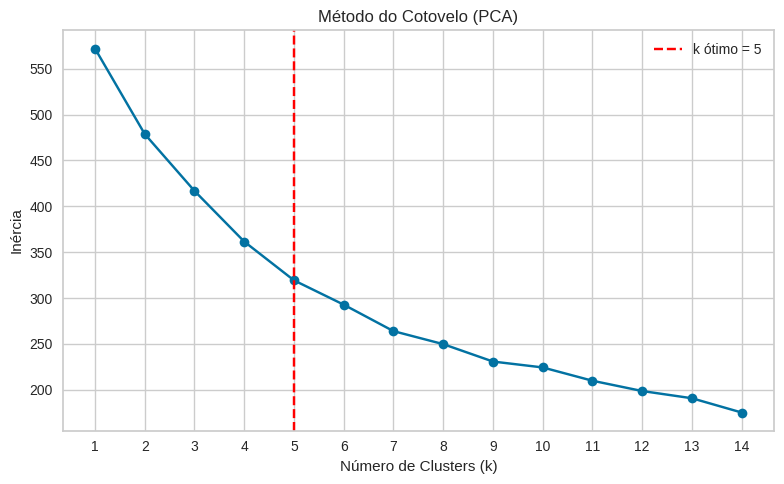

Número ideal de clusters (k) segundo o método do cotovelo: 5


In [11]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Aplicar PCA com 5 componentes
pca = PCA(n_components=5)
pca_data = pca.fit_transform(scaled_data)

# Calcular a inércia para cada k
inertia = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_data)
    inertia.append(kmeans.inertia_)

# Calcular o cotovelo pela curvatura (método do “joelho” geométrico)
# Linha reta entre primeiro e último ponto
x = np.array(list(k_range))
y = np.array(inertia)

# Vetor entre o primeiro e o último ponto
line_vec = np.array([x[-1] - x[0], y[-1] - y[0]])
line_vec = line_vec / np.sqrt(np.sum(line_vec**2))  # normaliza

# Vetor entre cada ponto e o primeiro
vec_from_first = np.array([x - x[0], y - y[0]]).T
# Projeção ortogonal na linha base
scalar_proj = np.dot(vec_from_first, line_vec)
proj = np.outer(scalar_proj, line_vec)
vec_to_line = vec_from_first - proj
dist_to_line = np.sqrt(np.sum(vec_to_line**2, axis=1))

# Índice de maior distância é o cotovelo
k_optimo = k_range[np.argmax(dist_to_line)]

# Exibir o gráfico
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.axvline(k_optimo, color='red', linestyle='--', label=f'k ótimo = {k_optimo}')
plt.title('Método do Cotovelo (PCA)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Mostrar o valor ideal encontrado
print(f"Número ideal de clusters (k) segundo o método do cotovelo: {k_optimo}")


## Prevendo a Classificação dos Municípios

In [12]:
# KMeans sobre os componentes principais
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clustering['Cluster'] = kmeans.fit_predict(pca_data)

In [13]:
#Visualizando os Municípios com seus Clusters
df_clustering.head()

,Município,Índice de Desmatamento (%),Cobertura Vegetal (%),Acesso à Água Potável (%),Renda Média Mensal (R$),Densidade Populacional (hab/km²),Frequência de Queimadas (ano),Distância de Área Urbana (km),Cluster
0,ACARÁ,58.15,43.25,85.55,1805.0,9.90,9.0,39.75,1
1,ALENQUER,29.10,32.20,68.60,1180.5,68.00,7.5,42.30,0
2,ALMEIRIM,32.50,78.80,87.60,1289.0,114.20,8.0,24.20,4
3,ALTAMIRA,54.20,89.00,70.90,2480.0,141.80,8.0,11.20,4
4,ANAJÁS,25.80,25.20,68.25,1722.0,114.35,5.0,86.15,0


## 🧠 Interpretação dos Componentes Principais por Cluster

A tabela abaixo apresenta as **médias dos componentes principais (PC1 a PC5)** para cada cluster identificado após aplicação da PCA e do algoritmo K-Means.

Esses valores indicam **quais dimensões ambientais e sociais são mais fortes ou mais frágeis** dentro de cada grupo de municípios.

| Cluster | PC1   | PC2   | PC3   | PC4   | PC5   |
|---------|-------|-------|-------|-------|-------|
| 0       | 0.65  | 0.41  | 1.07  | -0.38 | -0.14 |
| 1       | -0.26 | -0.67 | 0.40  | -0.46 | 1.20  |
| 2       | -0.40 | -1.20 | 0.04  | 0.39  | -0.98 |
| 3       | -1.15 | 0.97  | -0.31 | 0.17  | -0.13 |
| 4       | 1.39  | 0.06  | -1.08 | 0.23  | 0.10  |

---

### 📊 Interpretação dos Componentes

| PC | Principais Variáveis | Significado |
|----|----------------------|-------------|
| **PC1** | Densidade populacional, cobertura vegetal, renda, água potável | Infraestrutura urbana e qualidade ambiental |
| **PC2** | Distância urbana, queimadas, desmatamento | Isolamento e pressão ambiental |
| **PC3** | Queimadas, desmatamento, distância | Vulnerabilidade ambiental |
| **PC4** | Desmatamento, água potável | Relação entre pressão ambiental e infraestrutura básica |
| **PC5** | Acesso à água, desmatamento, densidade populacional | Desigualdade ambiental e estrutural |

---

### 🧩 Perfil dos Clusters

#### 🔴 Cluster 0
- **PC1 e PC3 positivos**
- Alta urbanização e densidade com **grande impacto ambiental**
- **Municípios com infraestrutura**, mas sob **forte pressão ambiental** (queimadas)

#### 🟢 Cluster 1
- **PC5 muito positivo**, **PC2 negativo**
- Boa infraestrutura e acesso à água, **pouca pressão ambiental**
- **Zonas urbanas ou periurbanas bem estruturadas**

#### 🟡 Cluster 2
- **PC2 e PC5 negativos**
- Próximos de áreas urbanas, mas com **carência em infraestrutura básica**
- Municípios com **vulnerabilidade social e ambiental combinada**

#### 🔵 Cluster 3
- **PC1 muito negativo**, **PC2 positivo**
- Baixa densidade e renda, **isolados geograficamente**, com alta pressão ambiental
- **Municípios rurais e periféricos** com pouca infraestrutura

#### 🟣 Cluster 4
- **PC1 muito positivo**, **PC3 negativo**
- Alta cobertura vegetal, renda e baixa queimada
- **Municípios com perfil preservado e sustentável**

In [14]:
# Estatísticas dos componentes principais por cluster
pca_df = pd.DataFrame(pca_data, columns=[f'PC{i+1}' for i in range(5)])
pca_df['Cluster'] = df_clustering['Cluster']
cluster_means = pca_df.groupby('Cluster').mean().round(2)

cluster_means

,PC1,PC2,PC3,PC4,PC5
Cluster,,,,,
0,0.65,0.41,1.07,-0.38,-0.14
1,-0.26,-0.67,0.40,-0.46,1.20
2,-0.40,-1.20,0.04,0.39,-0.98
3,-1.15,0.97,-0.31,0.17,-0.13
4,1.39,0.06,-1.08,0.23,0.10


###  📊 Gráfico de Barras - Comparação das Médias das Variáveis por Cluster

O gráfico acima apresenta a **comparação direta das médias das variáveis** ambientais e socioeconômicas entre os diferentes **clusters** formados no processo de agrupamento dos municípios do estado do Pará.

#### 🎯 Objetivo:
Permitir uma **análise visual das diferenças médias** entre os grupos formados, facilitando a identificação de padrões ou contrastes em cada variável.

#### 🧩 Elementos do Gráfico:
- **Eixo X**: Representa as **variáveis analisadas**, como:
  - Índice de Desmatamento (%)
  - Cobertura Vegetal (%)
  - Acesso à Água Potável (%)
  - Renda Média Mensal (R$)
  - Densidade Populacional (hab/km²)
  - Frequência de Queimadas (ano)
  - Distância de Área Urbana (km)
  
- **Eixo Y**: Mostra o valor **médio da variável para cada cluster**.

- **Cores das Barras**: Cada cor representa um cluster (0 a 4), conforme a legenda à direita.

#### 🧠 Principais Percepções:
- A **Renda Média Mensal (R$)** é a variável com maior amplitude entre os grupos, indicando grande desigualdade socioeconômica.
- O **Cluster 2** se destaca como o de **maior renda média**, mas não necessariamente com melhores indicadores ambientais.
- O **Cluster 4** apresenta **alta densidade populacional**, **boa cobertura vegetal**, e **acesso à água razoável**, sugerindo uma combinação de urbanização e conservação.
- O **Cluster 0** tem valores medianos em quase todas as variáveis, exceto por uma **distância elevada de áreas urbanas**, o que pode indicar isolamento.
- A **Frequência de Queimadas** é relativamente estável entre os clusters, exceto o 3 que apresenta valor reduzido.


In [15]:
#Visualizandoa as Estatísticas
estatisticas = df_clustering.groupby('Cluster')[features].mean().round(2)
estatisticas

,Índice de Desmatamento (%),Cobertura Vegetal (%),Acesso à Água Potável (%),Renda Média Mensal (R$),Densidade Populacional (hab/km²),Frequência de Queimadas (ano),Distância de Área Urbana (km)
Cluster,,,,,,,
0,34.27,48.38,76.76,1282.23,92.74,6.60,66.78
1,42.30,44.18,84.31,1779.00,53.20,6.80,36.15
2,34.63,58.15,47.62,1896.70,83.05,7.53,38.21
3,60.05,35.73,56.20,1787.30,69.66,3.37,59.20
4,62.72,66.97,75.71,1418.60,121.93,4.95,37.24


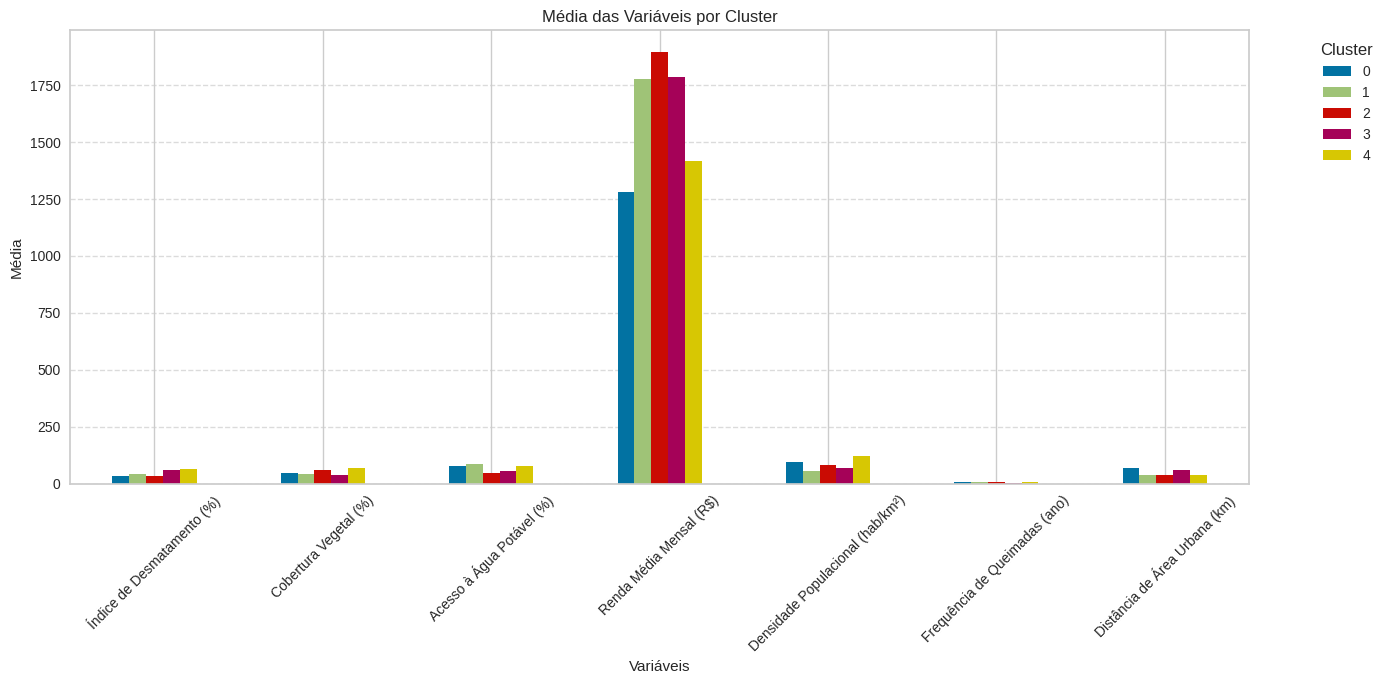

In [16]:
# Gráfico de barras das médias por variável e cluster
fig, ax = plt.subplots(figsize=(14, 7))
estatisticas.T.plot(kind='bar', ax=ax)

plt.title('Média das Variáveis por Cluster')
plt.xlabel('Variáveis')
plt.ylabel('Média')
plt.xticks(rotation=45)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Salvando os Dados do Projeto

- Salvando o Modelo
  - ``kmeans_pca.pkl``

- Salvando o DataFrame com os clusters
  - ``df_muncipios_classifications.csv``

In [17]:
import pickle

# Salvando o modelo
with open('kmeans_pca.pkl', 'wb') as file:
    pickle.dump(kmeans, file)
# Salvando o DataFrame
df_clustering.to_csv('df_muncipios_classifications.csv', index=False)

## ✅ Conclusão do Projeto

Este projeto fez parte de um **desafio proposto pela [I2A2 Instituto de Inteligência Artificial Aplicada](https://www.i2a2.academy/)**, com o objetivo de aplicar técnicas de **Análise de Agrupamento (Clustering)** para segmentar os municípios do estado do Pará com base em características ambientais, sociais e econômicas.

Por meio de técnicas como o **K-Means**, **Análise de Componentes Principais (PCA)** e **visualizações com heatmaps e gráficos comparativos**, foi possível identificar **padrões e semelhanças entre grupos de municípios**, evidenciando:

- Diferenças regionais marcantes em indicadores como **renda**, **desmatamento**, **acesso à água potável** e **frequência de queimadas**;
- Clusters com **alta cobertura vegetal** versus áreas com **alto índice de desmatamento**;
- Municípios com **alta densidade populacional e proximidade urbana**, contrastando com áreas mais **isoladas e de menor infraestrutura**.

Além disso, foram aplicadas estratégias de **normalização dos dados** para melhor comparação entre variáveis de escalas distintas, garantindo maior **clareza na interpretação visual** dos resultados.

Este estudo demonstra a importância da ciência de dados na **compreensão de realidades locais** e no apoio à **tomada de decisões orientadas por dados**, especialmente em contextos ambientais e de planejamento regional.

---
